In [16]:
import matplotlib.pyplot as plt
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
import scienceplots
import lovelyplots
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.isa import expected_costs
from gulps.utils.logging_config import logger
from gulps.utils.visualize import render_path

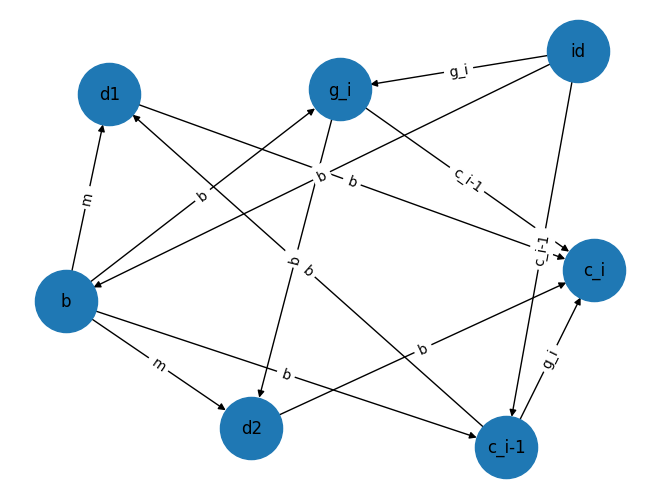

In [17]:
import networkx as nx

# Directed graph so the (from → to) structure is preserved
G = nx.DiGraph()

# Add edges with the form (from, label, to)
edges = [
    ("id", "b", "b"),
    ("b", "b", "c_i-1"),
    ("c_i-1", "b", "d1"),
    ("d1", "b", "c_i"),
    ("id", "c_i-1", "c_i-1"),
    ("c_i-1", "g_i", "c_i"),
    ("b", "m", "d1"),
    ("b", "b", "g_i"),
    ("g_i", "b", "d2"),
    ("d2", "b", "c_i"),
    ("id", "g_i", "g_i"),
    ("g_i", "c_i-1", "c_i"),
    ("b", "m", "d2"),
]

# Insert edges
for u, lbl, v in edges:
    G.add_edge(u, v, label=lbl)

import matplotlib.pyplot as plt

pos = nx.arf_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=12)
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.show()


In [18]:
from gulps.utils.recover_equiv import recover_local_equivalence


def recover_equivalent_circuit(target_gate, current_gate):
    k1, k2, k3, k4, global_phase = recover_local_equivalence(target_gate, current_gate)
    temp = QuantumCircuit(2, global_phase=global_phase)
    temp.append(UnitaryGate(k1), [0])
    temp.append(UnitaryGate(k2), [1])
    temp.append(current_gate, [0, 1])
    temp.append(UnitaryGate(k3), [0])
    temp.append(UnitaryGate(k4), [1])
    return temp


In [19]:
class BGate(UnitaryGate):
    def __init__(self, theta=np.pi / 2):
        """BGate(theta) constructor."""
        c1 = np.cos(theta / 4)
        c3 = np.cos(3 * theta / 4)
        s1 = np.sin(theta / 4)
        s3 = np.sin(3 * theta / 4)
        return super().__init__(
            [
                [c1, 0, 0, 1j * s1],
                [0, c3, 1j * s3, 0],
                [0, 1j * s3, c3, 0],
                [1j * s1, 0, 0, c1],
            ],
            label="b",
        )


def b_sandwich(target, interior_only=False, second_dagger=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    temp = QuantumCircuit(2)
    if interior_only:
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        return temp
    else:
        temp.append(BGate(), [0, 1])
        temp.ry(-2 * c1, 0)
        temp.rz(-b2, 1)
        temp.ry(-b1, 1)
        temp.rz(-b2, 1)
        if second_dagger:
            temp.u(np.pi, 0, 0, 0)
            temp.u(np.pi, -np.pi / 2, np.pi / 2, 1)
            temp.append(BGate().inverse(), [0, 1])
        else:
            temp.append(BGate(), [0, 1])
        return temp

In [34]:
b_sandwich(GateInvariants.from_weyl((0, 0, 0))).draw()
qc = QuantumCircuit(2)
qc.append(Operator(b_sandwich(GateInvariants.from_weyl((0, 0, 0)))), [0, 1])
qc.decompose().draw()

global phase: π/2
      ┌────────────┐ 
q_0: ─┤ U(0,-π,-π) ├─
     ┌┴────────────┴┐
q_1: ┤ U(0,π/2,π/2) ├
     └──────────────┘

In [4]:
isa = [
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

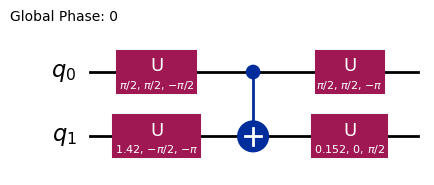

In [ ]:
qc = QuantumCircuit(2)
qc.append(Operator(BGate().to_matrix() @ BGate().to_matrix()), [0, 1])
qc.decompose().draw("mpl")

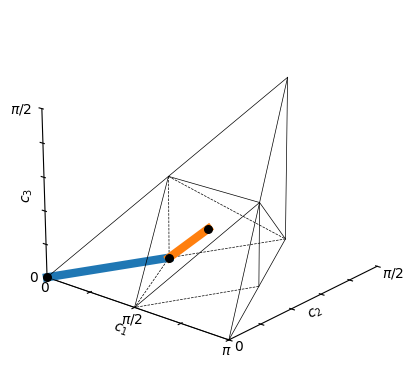

In [5]:
target = GateInvariants.from_weyl((0.5, 0.25, 0.25))
target = GateInvariants.from_unitary(random_unitary(4))
sentence_out, intermediates = decomposer._best_decomposition(target)
render_path(intermediates);

In [6]:
print(intermediates[0].weyl)
c1c2c3(Operator(b_sandwich(intermediates[0], second_dagger=True)))

[0.25 0.25 0.  ]


(np.float64(0.25), np.float64(0.25), np.float64(0.0))

In [7]:
def b_sandwich_interior_ops(target, second_dagger=False):
    # https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.93.020502
    c1, c2, c3 = np.pi * target.weyl / 2
    rb1 = 1 - 4 * np.sin(c2) ** 2 * np.cos(c3) ** 2
    b1 = np.arccos(rb1)
    rb2 = np.sqrt(
        np.cos(2 * c2) * np.cos(2 * c3) / (1 - 2 * np.sin(c2) ** 2 * np.cos(c3) ** 2)
    )
    b2 = np.arcsin(rb2)

    w1 = QuantumCircuit(1)
    w2 = QuantumCircuit(1)
    w1.ry(-2 * c1, 0)
    w2.rz(-b2, 0)
    w2.ry(-b1, 0)
    w2.rz(-b2, 0)
    if second_dagger:
        w1.u(np.pi, 0, 0, 0)
        w2.u(np.pi, -np.pi / 2, np.pi / 2, 0)
    return Operator(w1).data, Operator(w2).data

In [8]:
# step 1. B-sandwichs of Gi, C_i-1, C_i
K3L9d, K4L10d = b_sandwich_interior_ops(intermediates[0], second_dagger=True)  # C_i-1
L9L11, L10L12 = b_sandwich_interior_ops(sentence_out[1])  # Gi
K3L11, K4L12 = b_sandwich_interior_ops(intermediates[1])  # C_i

# # verify 0
# assert (
#     GateInvariants.from_unitary(Operator(b_sandwich(sentence_out[1])))
#     == sentence_out[1]
# )
# assert (
#     GateInvariants.from_unitary(
#         Operator(b_sandwich(intermediates[0], second_dagger=True))
#     )
#     == intermediates[0]
# )
# assert (
#     GateInvariants.from_unitary(Operator(b_sandwich(intermediates[1])))
#     == intermediates[1]
# )

# # verify 1
# assert np.allclose(K3L9d @ L9L11, K3L11)
# assert np.allclose(K4L10d @ L10L12, K4L12)

In [9]:
from numpy import kron

F1 = np.matrix(kron(K3L9d, K4L10d))
F2 = np.matrix(kron(L9L11, L10L12))
F3 = np.matrix(kron(K3L11, K4L12))

In [10]:
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F3, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[1].weyl)
c1c2c3(Operator(qc).data)

[ 0.39590858  0.29563696 -0.09613282]


(np.float64(0.39590858), np.float64(0.29563696), np.float64(0.09613282))

In [11]:
F1p = F3 @ F2.H
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F1p, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[0].weyl)
c1c2c3(Operator(qc).data)

[0.25 0.25 0.  ]


(np.float64(0.50383871), np.float64(0.14590858), np.float64(0.06431885))

In [12]:
F2p = F1.H @ F3
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F2p, [0, 1])
qc.append(BGate().inverse(), [0, 1])
print(sentence_out[0].weyl)
c1c2c3(Operator(qc).data)

[0.25 0.25 0.  ]


(np.float64(0.50383871), np.float64(0.14590858), np.float64(0.06431885))

In [13]:
F3p = F1 @ F2
qc = QuantumCircuit(2)
qc.append(BGate(), [0, 1])
qc.unitary(F3p, [0, 1])
qc.append(BGate(), [0, 1])
print(intermediates[1].weyl)
c1c2c3(Operator(qc).data)

[ 0.39590858  0.29563696 -0.09613282]


(np.float64(0.5), np.float64(0.0), np.float64(0.0))